# 02 - Análisis global de PyCEFR

Aquí se analiza qué niveles y constructos detecta la herramienta basada en PyCEFR en todo el corpus.

In [2]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEVEL_ORDER = {"A1": 1, "A2": 2, "B1": 3, "B2": 4, "C1": 5, "C2": 6}
LEVEL_ORDER_INV = {v: k for k, v in LEVEL_ORDER.items()}
RADON_RANK_ORDER = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6}
RADON_RANK_ORDER_INV = {v: k for k, v in RADON_RANK_ORDER.items()}

def clean_file_name(path):
    """Devuelve un nombre de fichero comparable entre herramientas."""
    return Path(str(path)).name

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def detect_json_kind(path):
    """Intenta detectar si un JSON parece de Radon o de PyCEFR."""
    try:
        data = load_json(path)
    except Exception:
        return "unknown"
    # Buscar un registro de ejemplo dentro del árbol project/file/[records]
    for project, files in data.items():
        if not isinstance(files, dict):
            continue
        for file_path, records in files.items():
            if isinstance(records, list) and records:
                rec = records[0]
                if isinstance(rec, dict):
                    if {"Class", "Start Line", "End Line", "Level"}.issubset(set(rec.keys())):
                        return "pycefr"
                    if {"type", "rank", "complexity", "lineno", "endline"}.issubset(set(rec.keys())):
                        return "radon"
    return "unknown"

In [3]:
df_pycefr = pd.read_csv(OUTPUT_DIR / "pycefr_constructs_global.csv")
df_pycefr.head()

,case,project,file,file_name,class,start_line,end_line,displacement,level,level_num,source_file
0,python-beginner-programming-exercises,11-Create-A-New-Function,test.py,test.py,'range' call function,25,25,13,A2,2,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1,python-beginner-programming-exercises,11-Create-A-New-Function,test.py,test.py,Files --> 'open' call function,32,32,9,A2,2,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
2,python-beginner-programming-exercises,11-Create-A-New-Function,test.py,test.py,Files --> 'read' call function,33,33,18,A2,2,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
3,python-beginner-programming-exercises,11-Create-A-New-Function,test.py,test.py,Simple Atributte,11,11,1,A2,2,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
4,python-beginner-programming-exercises,11-Create-A-New-Function,test.py,test.py,Simple Atributte,20,20,1,A2,2,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...


In [4]:
level_counts = df_pycefr["level"].value_counts().reindex(LEVEL_ORDER.keys(), fill_value=0)
level_counts

level
A1    500
A2    535
B1     63
B2     55
C1     23
C2      0
Name: count, dtype: int64

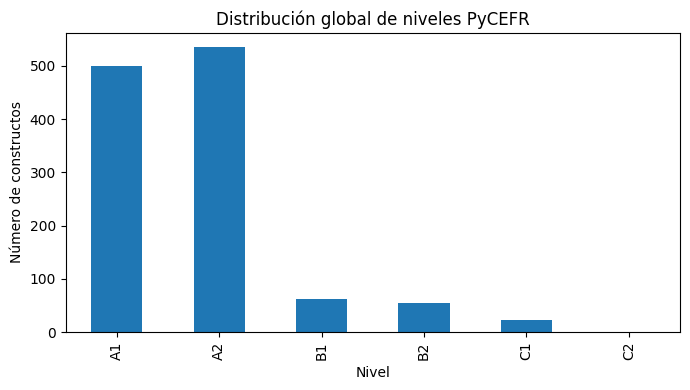

In [5]:
plt.figure(figsize=(7,4))
level_counts.plot(kind="bar")
plt.title("Distribución global de niveles PyCEFR")
plt.xlabel("Nivel")
plt.ylabel("Número de constructos")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_pycefr_distribucion_niveles.png", dpi=150)
plt.show()

In [6]:
top_classes = df_pycefr["class"].value_counts().head(20)
top_classes

class
Simple Atributte                          371
Simple Assignment                         147
Alias                                     135
Import                                     85
Function                                   57
'assert' exception                         55
Print                                      30
Function with Simple argument              29
Files --> 'open' call function             21
'raise' exception                          21
Exception --> try/except                   21
Except Handler                             21
Assigment with sum (total = total + 1)     20
With                                       20
Files --> 'read' call function             19
Return                                     18
Import're' module                          17
From                                       14
'range' call function                      13
Simple For Loop                            11
Name: count, dtype: int64

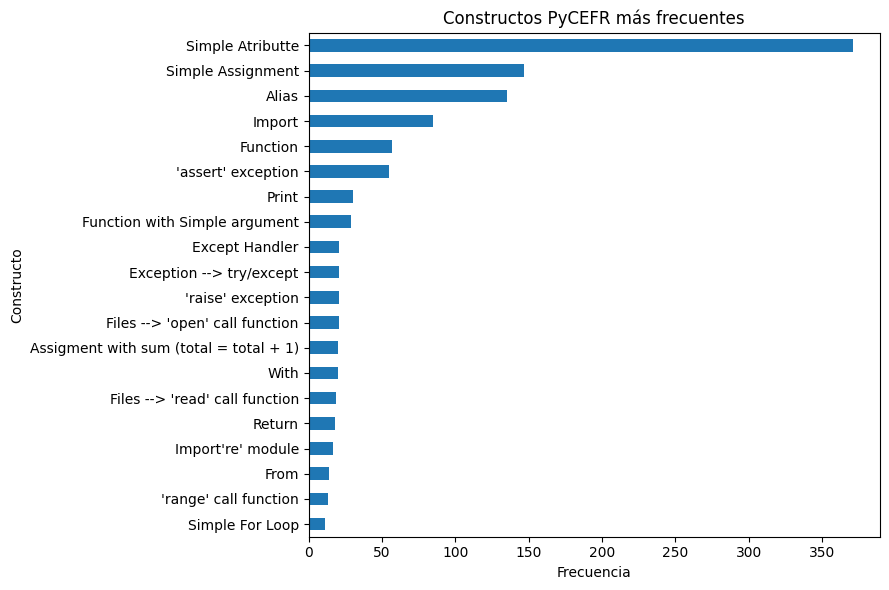

In [7]:
plt.figure(figsize=(9,6))
top_classes.sort_values().plot(kind="barh")
plt.title("Constructos PyCEFR más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Constructo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_pycefr_top_constructos.png", dpi=150)
plt.show()

In [8]:
pycefr_by_case = (
    df_pycefr.groupby("case")
    .agg(
        n_constructs=("class", "count"),
        n_classes=("class", "nunique"),
        max_level_num=("level_num", "max"),
        mean_level_num=("level_num", "mean"),
        max_displacement=("displacement", "max"),
    )
    .reset_index()
)
pycefr_by_case["max_level"] = pycefr_by_case["max_level_num"].map(LEVEL_ORDER_INV)
pycefr_by_case.sort_values(["max_level_num", "n_constructs"], ascending=False)

,case,n_constructs,n_classes,max_level_num,mean_level_num,max_displacement,max_level
0,python-beginner-programming-exercises,1176,32,5,1.780612,531,C1


In [9]:
pycefr_high = df_pycefr[df_pycefr["level_num"] >= 4].sort_values(["level_num", "case", "file_name"], ascending=[False, True, True])
pycefr_high.head(50)

,case,project,file,file_name,class,start_line,end_line,displacement,level,level_num,source_file
50,python-beginner-programming-exercises,11-Create-A-New-Function,test.py,test.py,Import're' module,5,5,0,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
124,python-beginner-programming-exercises,04-Multiply-Two-Values,test.py,test.py,Import're' module,8,8,0,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
171,python-beginner-programming-exercises,06-String-Concatenation,test.py,test.py,Import're' module,1,1,0,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
253,python-beginner-programming-exercises,09-Random-Numbers,test.py,test.py,Import're' module,8,8,0,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
357,python-beginner-programming-exercises,17-Russian-Roulette,test.py,test.py,Simple List Comprehension,30,30,14,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
358,python-beginner-programming-exercises,17-Russian-Roulette,test.py,test.py,List Comprehension with 1If statements,31,31,18,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
375,python-beginner-programming-exercises,17-Russian-Roulette,test.py,test.py,Import're' module,8,8,0,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
447,python-beginner-programming-exercises,14-Create-A-For-Loop,test.py,test.py,Simple List Comprehension,29,29,15,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
448,python-beginner-programming-exercises,14-Create-A-For-Loop,test.py,test.py,Simple List Comprehension,30,30,17,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
472,python-beginner-programming-exercises,14-Create-A-For-Loop,test.py,test.py,Import're' module,9,9,0,C1,5,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...


In [10]:
pycefr_by_case.to_csv(OUTPUT_DIR / "02_pycefr_resumen_por_caso.csv", index=False)
pycefr_high.to_csv(OUTPUT_DIR / "02_pycefr_constructos_alto_nivel.csv", index=False)

## Comentario para la memoria

Este análisis permite identificar qué tipos de constructos aparecen con mayor frecuencia y cuáles son los niveles más habituales. También permite localizar constructos avanzados, como comprensiones, generadores, estructuras anidadas o excepciones, que pueden explicar por qué PyCEFR asigna niveles más altos aunque la complejidad ciclomática no sea necesariamente elevada.